# **LONG SHORT-TERM MEMORY (LSTM)**

## **O PROBLEMA DAS DEPENDÊNCIAS DE LONGO PRAZO E DO GRADIENTE**

Como comentado anteriormente, uma das principais revoluções das *RNNs* é a característica de conectar informações anteriores à tarefa atual, garantindo que o passado possa "interferir" na tomada de decisão para prever o futuro.

Às vezes, precisamos apenas examinar informações recentes para executar a tarefa atual. Por exemplo, considere um modelo de linguagem tentando prever a próxima palavra com base nas anteriores. Se estamos tentando prever a última palavra em “as nuvens estão no ___”, não precisamos de mais nenhum contexto — é bastante óbvio que a próxima palavra será o **céu**. Nesses casos, onde a distância entre as informações relevantes e o que quero prever é pequena, as *RNNs* conseguem aprender bem.

No entanto, existem casos em que precisamos de mais contexto. Por exemplo, vamos tentar prever a última palavra no texto "Eu cresci na França, morei lá por 18 anos, até o ano passado, e falo fluentemente ____". Informações recentes sugerem que a próxima palavra é provavelmente o nome de uma língua, mas se quisermos saber precisamente qual idioma, precisamos do contexto da França, de mais para trás. Nota-se que a distância da palavra que queremos prever para as informações necessárias para isso cresceu, em comparação com o exemplo anterior. Nesses casos, à medida que essa distância aumenta, as *RNNs* tornam-se incapazes de manter e aprender a conectar as informações.

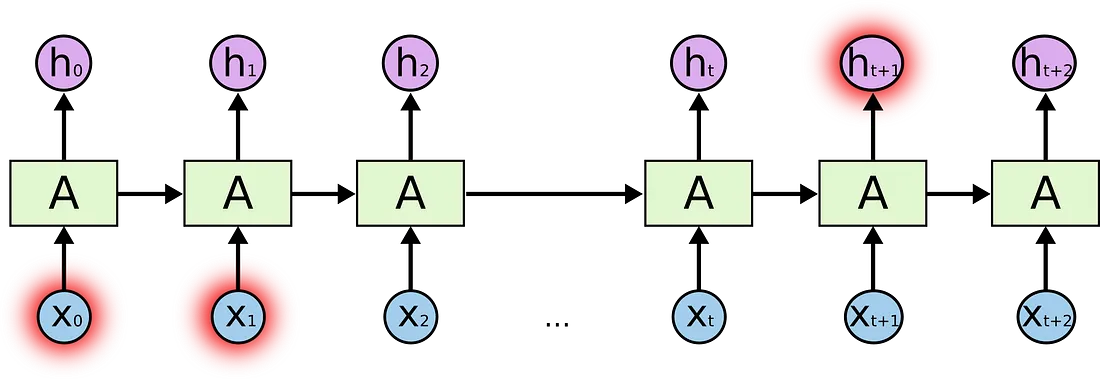 *A saída ht+1 provavelmente não consegue mais levar a entrada X0 e X1 em consideração.*

Na teoria, as *RNNs* conseguiriam aprender e lidar com essas dependências de longo prazo. Porém, na prática, os *RNNs* não parecem capazes de aprendê-las.

Além desse problema, como comentado no material passado, o algoritmo de aprendizado baseado no *backpropagation* pelo tempo faz com que pesos se multipliquem muitas vezes repetidamente. Isso pode fazer com que o gradiente exploda (isso pode ser corrigido com a técnica *clipping*, onde o gradiente é limitado, ou seja, se ele passar de um valor x, ele receberá esse valor x ou outro valor) ou com que ele desapareça, esse já é mais difícil de tratar. Com isso que pode acontecer com o gradiente, o aprendizado se torna difícil de ser realizado.

## **AS REDES LSTM**

As redes de **Memória de Curto Longo Prazo (LSTM - Long Short-Term Memory)** surgem para suprir essa necessidade de aprender dependências de longo prazo. Elas foram projetadas para isso, ou seja, lembrar informações por longos períodos de tempo é praticamente o seu comportamento padrão.

As redes recorrentes possuem uma estrutura de repetição que se repete durante o tempo. Nas *RNNs* padrão, esta estrutura de repetição é bem simples, entrada, pesos, função de ativação e saída.

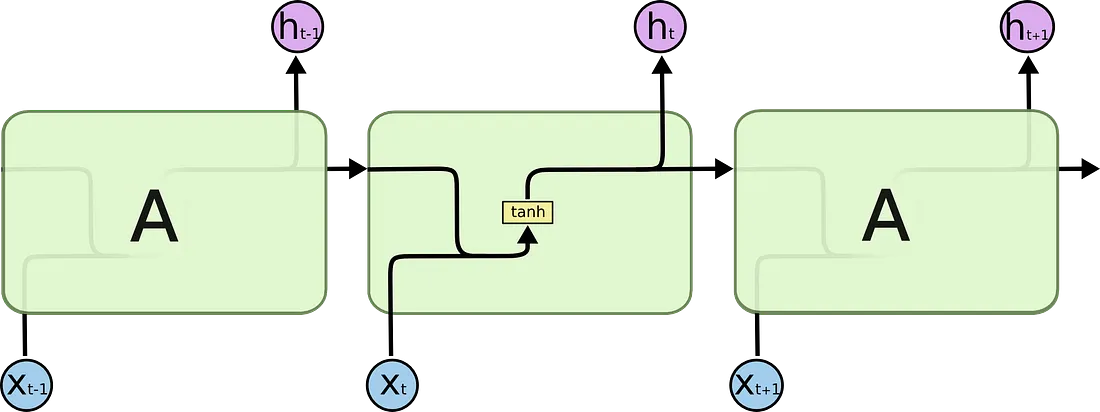 *Estrutura das RNNs padrão desenrolada pelo tempo.*

As *LSTMs* também possuem essa característica de se repetir durante o tempo. Porém o seu interior, o que acontece a cada passo de tempó é mais complexo do que nas *RNNs* padrão. Pois elas introduzem os *gates*, estruturas importantes para a manutenção de informações de longo e curto prazo.

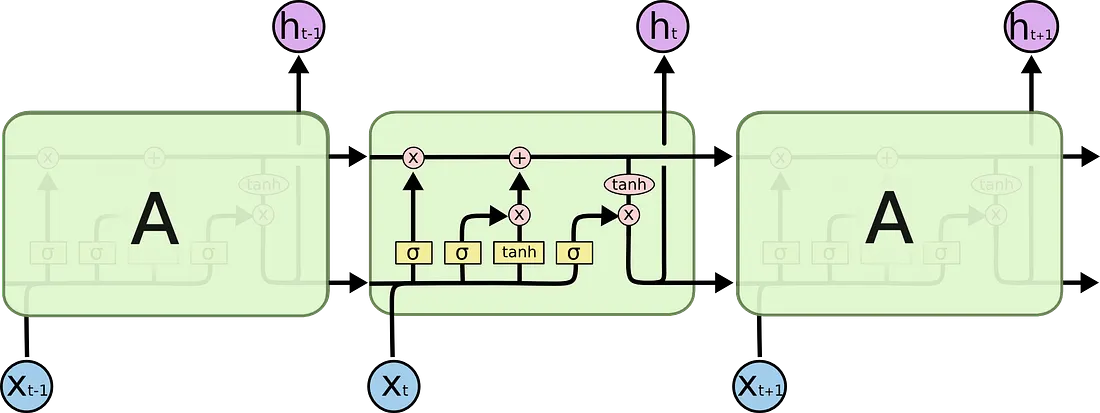 *Estrutura da LSTM desenrolado pelo tempo. Essa linha que passa abaixo dos sigmóides pode ser interpretada como a memória de curto prazo.*

Uma peça fundamental do *LSTM* é o estado da célula (***cell state***), que é a linha horizontal que passa pela parte superior da estrutura. O *cell state* é importante pois ele percorre toda a estrutura, sofrendo somente algumas operações pequenas como multiplicação e soma, não há pesos nem *biases* que possam modificá-lo. Por ele é fácil que as informações fluam sem alterações. Podemos considerá-lo como a memória de longo prazo. Essa falta de pesos permite que as memórias de longo prazo fluam através de vários passos de tempo sem fazer com que o gradiente exploda ou desapareça.

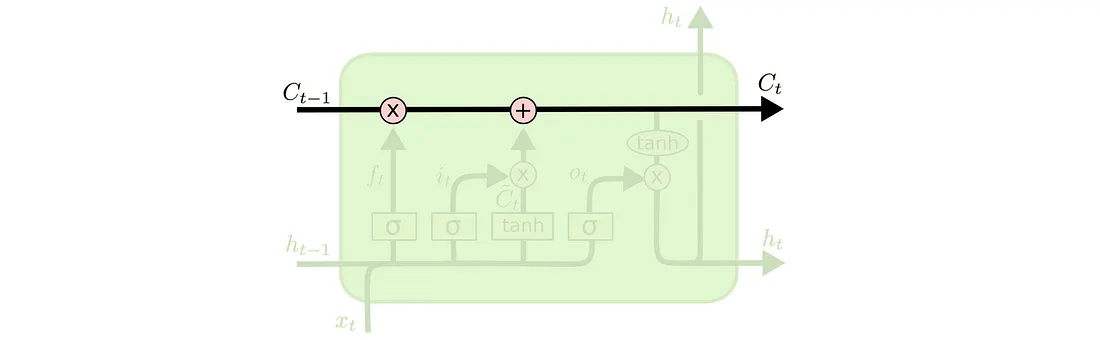

Por meio dos *gates*, o *LSTM* tem a capacidade de remover ou adicionar informações ao *cell state*. Os *gates* são compostos por uma camada de rede neural *sigmóide* e uma operação pontual. Nota-se, na imagem da estrutura do *LSTM*, que possuem 3 *gates* que controlam o *cell state*. A camada da *sigmóide*, como já comentei em materiais passados, produz resultados de saída **entre o 0 e o 1**, ou seja, o valor 0 significa **"não deixe nada passar"/"esqueça tudo"**, já o valor de 1 significa **"deixe passar tudo"/"lembre de tudo"** 

O primeiro passo do *LSTM* é decidir quais informações descartar do *cell state*. Esta decisão é tomada por uma camada *sigmóide*, ou seja, um *gate*, chamado *forget gate*. Ele analisa o input **Xt** e a saída do passo de tempo anterior **ht-1** e gera um número entre 0 e 1 para os valores do *cell state*. 1 representando **"mantenha isso completamente"** e 0 representando **"livre-se disso completamente"**. No exemplo de um modelo de linguagem que tenta prever a próxima palavra com base em todas as anteriores, o *cell state* pode conter o gênero do presente sujeito, para que os pronomes corretos sejam usados. Quando vemos um novo assunto, queremos esquecer o gênero do sujeito antigo.

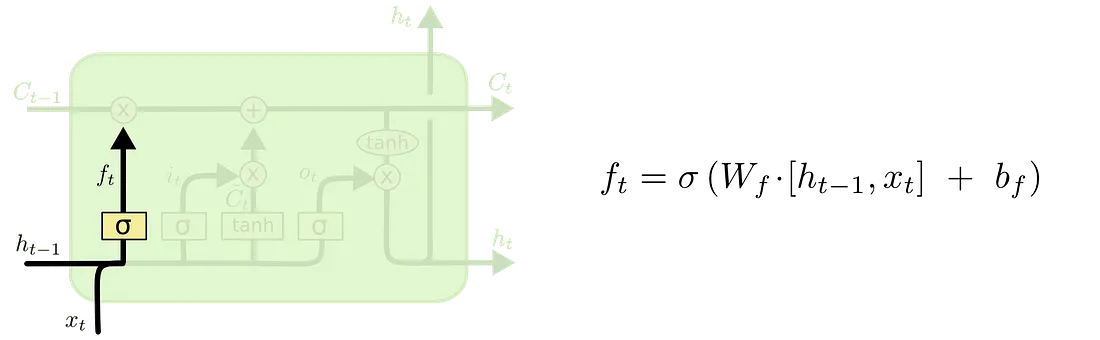 *Forget gate*


O próximo passo é decidir quais novas informações armazenar no *cell state*. Isso é dividido em duas partes. Uma parte é a camada da *tanh* que recebe os valores do passo de tempo passado e o *input* atual (pense nisso como a quantidade potencial a ser adicionada no *cell state*, ou seja, a potencial memória de longo prazo). Outra parte é a *sigmóide*, chamada de *input gate*, que decide a atualização do *cell state*, pois como a saída da *sigmóide* é entre 0 e 1, ela controla qual porcentagem da potencial memória de longo prazo será adicionada ao *cell state*, alterando a memória de longo prazo (ou não).

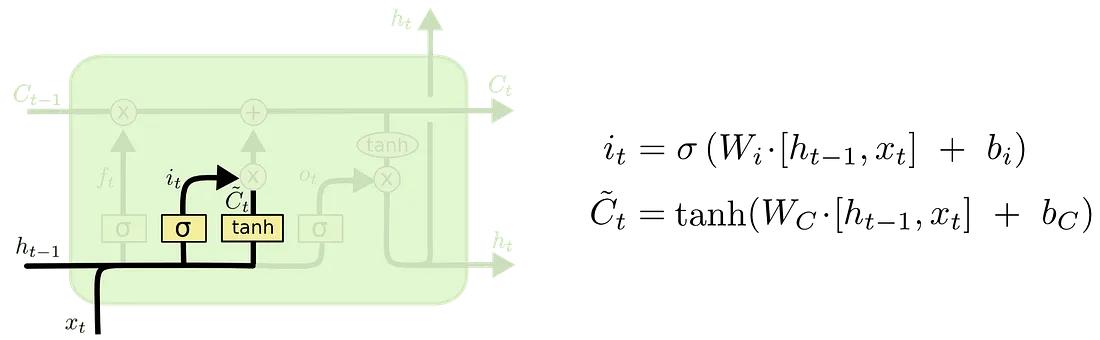 *Input gate*

Outra parte é a atualização do *cell state* antigo, *Ct-1*, para o novo *Ct*. Os passos anteriores já decidiram o que fazer, agora é so executar. Multiplica-se o antigo *cell state* pela saída do *forget gate*, esquecendo o alguma parte antiga ou mantendo tudo. Após isso, adiciona-se a saída da multiplicação da saída *input gate* pela saída da camada da *tanh* à esse valor do *cell state* obtido anteriormente. Com isso, atualiza-se o *cell state*, ou seja, a nossa memória de longo prazo. No exemplo do modelo de linguagem, é aqui que realmente retiramos as informações sobre o gênero do antigo e adicionamos as novas informações, conforme decidimos nas etapas anteriores.

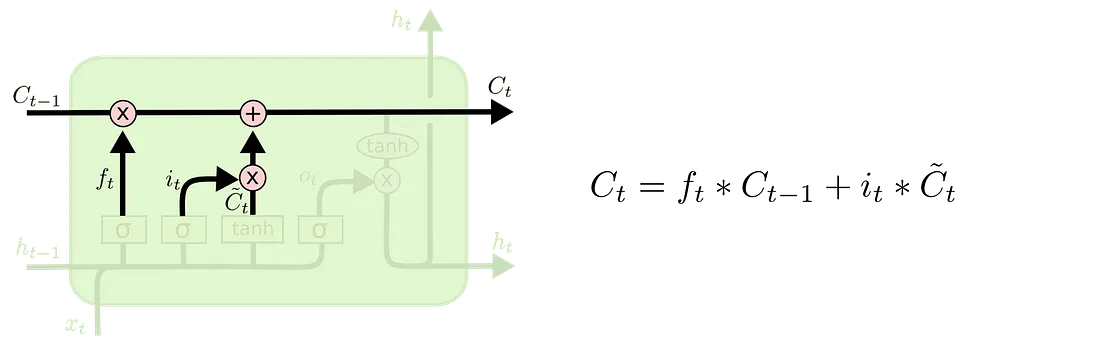 *Atualização do cell state*

Por final, essa "camada" tem que ter uma saída. Essa saída é baseada tanto no *cell state*, memória de longo prazo, quanto no *input* do passo de tempo atual e na sáída do passo de tempo atual anterior, memória de curto prazo. Primeiro, o *input* e a saída anterior passam por uma *sigmóide* que decidirá a porcentagem do *cell state* que será a nossa saída do passo de tempo, isso é conhecido como *output gate*. O *cell state* passa por uma *tanh* e é multiplicado pela saída da *sigmóide*, saindo assim um valor entre -1 e 1.

No exemplo do modelo de linguagem, como ele acabou de ver um sujeito, ele pode querer gerar informações relevantes para um verbo, caso seja o que vem a seguir. Por exemplo, ele pode indicar se o sujeito é singular ou plural, para que saibamos em que forma um verbo deve ser conjugado.

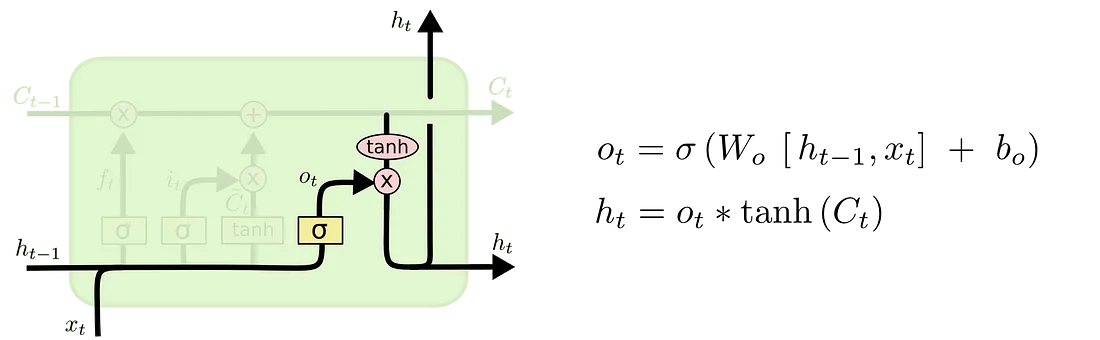 *Output gate*

**INDICAÇÃO DE MATERIAL COMPLEMENTAR SOBRE LSTM** : [Long Short-Term Memory (LSTM), claramente explicado](https://www.youtube.com/watch?v=YCzL96nL7j0&t=78s)

## **GATED RECURRENT UNIT (GRU)**